In [1]:
# =====================================================
# PHASE 2: HIGH-PASS DMF-NET TRAINING SCRIPT
# =====================================================

import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}

===== MODEL PARAMETERS =====
Total Parameters:     13,926,084
Trainable Parameters: 13,926,084

Epoch [1/15]
Train Loss: 0.0608 | Train Acc: 0.9808
Val Loss:   0.0079 | Val Acc:   0.9970

Epoch [2/15]
Train Loss: 0.0235 | Train Acc: 0.9934
Val Loss:   0.0064 | Val Acc:   0.9990

Epoch [3/15]
Train Loss: 0.0216 | Train Acc: 0.9949
Val Loss:   0.0010 | Val Acc:   1.0000

Epoch [4/15]
Train Loss: 0.0104 | Train Acc: 0.9966
Val Loss:   0.0019 | Val Acc:   0.9990

Epoch [5/15]
Train Loss: 0.0060 | Train Acc: 0.9986
Val Loss:   0.0050 | Val Acc:   0.9980

Epoch [6/15]
Train Loss: 0.0099 | Train Acc: 0.9972
Val Loss:   0.0010 | Val Acc:   1.0000

Epoch [7/15]
Train Loss: 0.0029 | Train Acc: 0.9991
Val Loss:   0.0005 | Val Acc:   1.0000

Epoch [8/15]
Train Loss: 0.0020 | Train Acc: 0.9996
Val Loss:   0.0005 | Val Acc:   1.0000

Epoch [9/15]
Train Loss: 0.0013 | Train Acc: 0.9996
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [10/15]
Trai

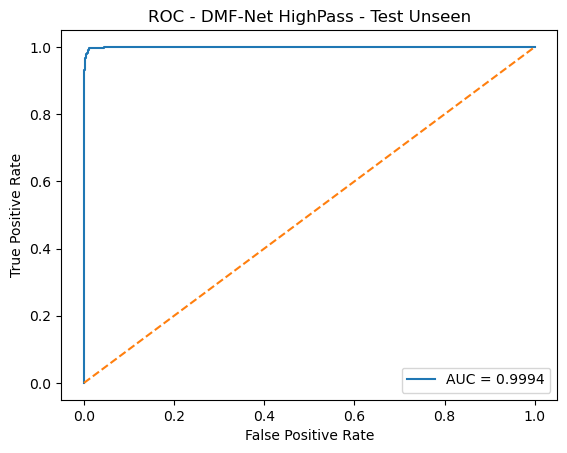

In [2]:
# ===============================
# 1️⃣ REPRODUCIBILITY
# ===============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===============================
# 2️⃣ CONFIG (PHASE 2 - DMFNET)
# ===============================
DATA_ROOT = r"D:\Datasets\Phase2_224x224_HighPass"
MODEL_SAVE_PATH = r"D:\MinorProject\MinorProject6thSem\models\best_dmfnet_highpass_phase2.pth"

BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ===============================
# 3️⃣ TRANSFORMS
# ===============================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# 4️⃣ DATASETS
# ===============================
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=test_transform)
test_seen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_seen"), transform=test_transform)
test_unseen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_unseen"), transform=test_transform)

print("Class mapping:", train_dataset.class_to_idx)

# ===============================
# 5️⃣ DATALOADERS
# ===============================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ===============================
# 6️⃣ DMF-NET MODEL
# ===============================

class DMFNet(nn.Module):
    def __init__(self):
        super(DMFNet, self).__init__()

        # Branch A: ResNet18
        weights_res = models.ResNet18_Weights.DEFAULT
        self.resnet = models.resnet18(weights=weights_res)
        self.resnet.fc = nn.Identity()

        # Branch B: MobileNetV2
        weights_mob = models.MobileNet_V2_Weights.DEFAULT
        self.mobilenet = models.mobilenet_v2(weights=weights_mob)
        self.mobilenet.classifier = nn.Identity()

        # Projection layers
        self.proj_res = nn.Linear(512, 256)
        self.proj_mob = nn.Linear(1280, 256)

        # Gating network
        self.gate = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

        self.classifier = nn.Linear(256, 2)

    def forward(self, x):
        feat_res = self.resnet(x)
        feat_mob = self.mobilenet(x)

        proj_res = self.proj_res(feat_res)
        proj_mob = self.proj_mob(feat_mob)

        combined = torch.cat([proj_res, proj_mob], dim=1)

        gate_logits = self.gate(combined)
        gate_weights = torch.softmax(gate_logits, dim=1)

        w_res = gate_weights[:, 0].unsqueeze(1)
        w_mob = gate_weights[:, 1].unsqueeze(1)

        fused = w_res * proj_res + w_mob * proj_mob

        output = self.classifier(fused)
        return output

model = DMFNet().to(DEVICE)

# ===============================
# 🔢 PARAMETER COUNT
# ===============================
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

print("\n===== MODEL PARAMETERS =====")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# ===============================
# 7️⃣ LOSS, OPTIMIZER, SCHEDULER
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ===============================
# 8️⃣ EVALUATION FUNCTION
# ===============================
def evaluate(model, loader, return_preds=False, return_probs=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = F.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if return_probs:
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    if return_preds and return_probs:
        return avg_loss, accuracy, all_preds, all_labels, all_probs
    if return_preds:
        return avg_loss, accuracy, all_preds, all_labels

    return avg_loss, accuracy

# ===============================
# 9️⃣ TRAINING LOOP
# ===============================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc = running_corrects / total
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# ===============================
# 🔟 SAVE BEST MODEL
# ===============================
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("\nBest model saved locally.")

# ===============================
# 1️⃣1️⃣ FINAL EVALUATION
# ===============================
train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)

test_seen_loss, test_seen_acc, seen_preds, seen_labels = evaluate(
    model, test_seen_loader, return_preds=True
)

test_unseen_loss, test_unseen_acc, unseen_preds, unseen_labels, unseen_probs = evaluate(
    model, test_unseen_loader, return_preds=True, return_probs=True
)

fpr, tpr, thresholds = roc_curve(unseen_labels, unseen_probs)
roc_auc = auc(fpr, tpr)

print("\n===== FINAL RESULTS =====")
print(f"Train Loss:       {train_loss:.4f} | Train Acc:       {train_acc:.4f}")
print(f"Validation Loss:  {val_loss:.4f} | Validation Acc:  {val_acc:.4f}")
print(f"Test Seen Loss:   {test_seen_loss:.4f} | Test Seen Acc:   {test_seen_acc:.4f}")
print(f"Test Unseen Loss: {test_unseen_loss:.4f} | Test Unseen Acc: {test_unseen_acc:.4f}")
print(f"Test Unseen AUC:  {roc_auc:.4f}")

print("\nConfusion Matrix - Test Unseen")
print(confusion_matrix(unseen_labels, unseen_preds))
print(classification_report(unseen_labels, unseen_preds))

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - DMF-Net HighPass - Test Unseen")
plt.legend()
plt.show()